<a href="https://colab.research.google.com/github/prabuddhayogi/ai-with-python/blob/CNN/CNN_fer2013_revisit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Image classification Project:
Dataset : Fer2023plus, link:
Project goal: Train the model to identify the image classification based on sentiment ( sad, happy, anger, etc)
Libraries used : pandas, numpy, matplotlib, os, cv2
Model : CNN , sigmoid

In [5]:
import os
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import random


# -----------------------------
# PATHS
# -----------------------------
raw_train_path = "/content/drive/MyDrive/AI-python/lecture39/image_folder/train_data"
clean_path = "/content/drive/MyDrive/AI-python/lecture39/cleaned_train"
processed_path = "/content/drive/MyDrive/AI-python/lecture39/processed_train"

IMG_SIZE = 48  # keep original 48x48
blur_threshold = 100  # for detecting blurry images
min_size = 40         # minimum image height/width

Create folders

In [6]:
# Create empty folder structure for clean and processed images
for emotion in os.listdir(raw_train_path):
    emotion_path = os.path.join(raw_train_path, emotion)
    if not os.path.isdir(emotion_path):
        continue
    os.makedirs(os.path.join(clean_path, emotion), exist_ok=True)
    os.makedirs(os.path.join(processed_path, emotion), exist_ok=True)

print("Folder structure for clean and processed images created!")

Folder structure for clean and processed images created!


Initialize counters and list

In [7]:
# -----------------------------
# INITIALIZE COUNTERS
# -----------------------------
corrupt_count = 0
blurred_count = 0
small_removed_count = 0
kept_count = 0

final_images = []
labels = []
label_map = {}

Pre-processing

In [8]:
for idx, emotion in enumerate(os.listdir(raw_train_path)):
    emotion_path = os.path.join(raw_train_path, emotion)
    if not os.path.isdir(emotion_path):
        continue

    # Map label index
    label_map[idx] = emotion

    for file in os.listdir(emotion_path):
        input_path = os.path.join(emotion_path, file)

        # 1:  Check for corrupt image
        try:
            img_pil = Image.open(input_path)
            img_pil.verify()
        except:
            corrupt_count += 1
            print("Corrupted image removed:", file)
            continue

        # 2️:  Read image
        img = cv2.imread(input_path)
        if img is None:
            corrupt_count += 1
            continue

        h, w = img.shape[:2]

        # 3️: Remove small images
        if h < min_size or w < min_size:
            small_removed_count += 1
            print("Removed small image:", file)
            continue

        # 4️: Remove blurry images
        gray_tmp = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        blur_value = cv2.Laplacian(gray_tmp, cv2.CV_64F).var()
        if blur_value < blur_threshold:
            blurred_count += 1
            print("Removed blurry image:", file)
            continue

        # 5️:  Save clean image
        output_clean_path = os.path.join(clean_path, emotion, file)
        cv2.imwrite(output_clean_path, img)
        kept_count += 1

        # 6️: Pre-process image for CNN
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        equalized = cv2.equalizeHist(gray)

        if IMG_SIZE != 48:
            equalized = cv2.resize(equalized, (IMG_SIZE, IMG_SIZE))

        # Save processed image
        output_processed_path = os.path.join(processed_path, emotion, file)
        cv2.imwrite(output_processed_path, equalized)

        # Append to final lists
        final_images.append(equalized)
        labels.append(idx)

Image vectorization for CNN

In [9]:
X = np.array(final_images) / 255.0  # normalize to 0-1
y = np.array(labels)

# Add channel dimension
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (800, 48, 48, 1)
Shape of y: (800,)


Summary:

In [10]:
print("\n================ SUMMARY ================")
print(f"Total images processed: {len(final_images)}")
print(f"Corrupted images removed: {corrupt_count}")
print(f"Small images removed: {small_removed_count}")
print(f"Blurry images removed: {blurred_count}")
print(f"Images kept: {kept_count}")
print("Number of classes:", len(label_map))
print("Label map:", label_map)
print("========================================\n")


================ SUMMARY ================
Total images processed: 800
Corrupted images removed: 0
Small images removed: 0
Blurry images removed: 0
Images kept: 800
Number of classes: 8
Label map: {0: 'anger', 1: 'contempt', 2: 'disgust', 3: 'fear', 4: 'happiness', 5: 'neutral', 6: 'sadness', 7: 'surprise'}



Visualization example :

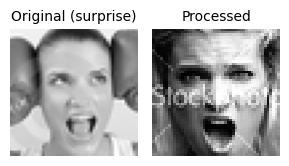

In [29]:

i = random.randint(0, len(final_images)-1)
emotion_label = label_map[y[i]]

raw_sample_path = os.path.join(raw_train_path, emotion_label, os.listdir(os.path.join(raw_train_path, emotion_label))[0])
raw_sample = cv2.imread(raw_sample_path)
raw_sample = cv2.cvtColor(raw_sample, cv2.COLOR_BGR2RGB)

processed_sample = final_images[i]

# -------------------------
# Updated figure size for subplots
# -------------------------
plt.figure(figsize=(3,3))  # wider for 2 subplots

# Original image
plt.subplot(1,2,1)
plt.imshow(raw_sample)
plt.title(f"Original ({emotion_label})", fontsize=10)
plt.axis("off")

# Processed image
plt.subplot(1,2,2)
plt.imshow(processed_sample, cmap="gray", interpolation='nearest')
plt.title("Processed", fontsize=10)
plt.axis("off")

plt.tight_layout()  # Fix overlapping titles
plt.show()

In [12]:
# Split data
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (640, 48, 48, 1)
Validation shape: (160, 48, 48, 1)


In [13]:
num_classes = len(set(y))

y_train = to_categorical(y_train, num_classes)
y_val = to_categorical(y_val, num_classes)

print("Number of classes:", num_classes)

Number of classes: 8


In [14]:
model = Sequential()

# Block 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(48,48,1)))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

# Block 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

# Block 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.25))

# Fully Connected
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# Output layer
model.add(Dense(num_classes, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 46, 46, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 21, 21, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 356,872 (1.36 MB)

 Trainable params: 356,424 (1.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [15]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 307ms/step - accuracy: 0.1375 - loss: 3.2448 - val_accuracy: 0.1125 - val_loss: 2.2345
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 164ms/step - accuracy: 0.1766 - loss: 2.0761 - val_accuracy: 0.1250 - val_loss: 3.3066
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 175ms/step - accuracy: 0.1844 - loss: 2.0427 - val_accuracy: 0.1437 - val_loss: 4.3758
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 269ms/step - accuracy: 0.1859 - loss: 2.0294 - val_accuracy: 0.1437 - val_loss: 5.0775
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 202ms/step - accuracy: 0.2109 - loss: 2.0167 - val_accuracy: 0.1250 - val_loss: 6.0416


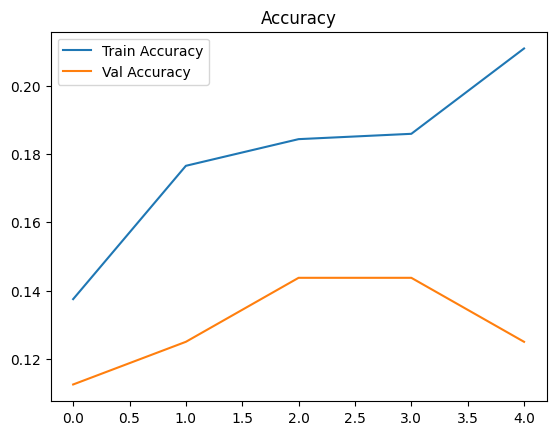

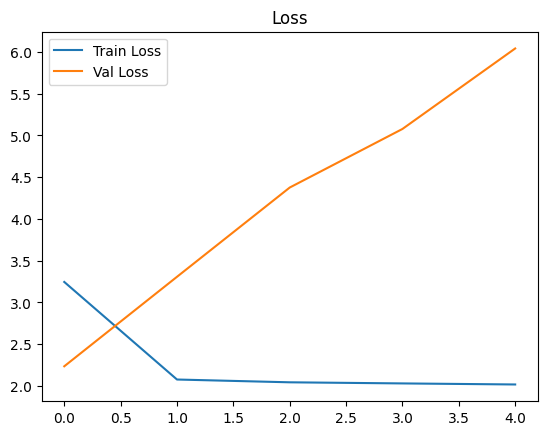

In [17]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [18]:
loss, acc = model.evaluate(X_val, y_val)
print("Validation Accuracy:", acc)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.1250 - loss: 6.0416
Validation Accuracy: 0.125


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted: disgust
Actual: happiness


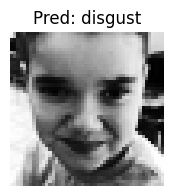

In [25]:
import random

i = random.randint(0, len(X_val)-1)

sample = X_val[i].reshape(1,48,48,1)
prediction = model.predict(sample)

predicted_class = np.argmax(prediction)
true_class = np.argmax(y_val[i])

print("Predicted:", label_map[predicted_class])
print("Actual:", label_map[true_class])

plt.figure(figsize=(2,2))  # fix blur
plt.imshow(X_val[i].reshape(48,48), cmap='gray', interpolation='nearest')  # fix blur
plt.title(f"Pred: {label_map[predicted_class]}")
plt.axis("off")
plt.show()